<a href="https://colab.research.google.com/github/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/4_introduccion_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

environment config


In [1]:
import sys
import sklearn
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
#-------------------------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
#
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
#-------------------------------------------------------------------------------


os.environ["TF_CPP_MIN_LOG_LEVEL"] = '2' # Suppress TensorFlow logging (1)	

gpus = tf.config.list_physical_devices('GPU')

# Activar memory growth (debe hacerse antes de crear tensores)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print('\nMemory growth activado para', gpu)
    except Exception as e:
        print('\nNo se pudo activar memory growth para', gpu, '->', e)






Memory growth activado para PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Procesamiento de secuencias con redes neuronales recurrentes

- En general, muchos problemas en ciencia de datos, requieren del procesado de datos sencuenciales, generalmente asociados al tiempo (series de tiempo).

- En ese sentido, sea la serie de datos $\{x_t\in\mathbb{R}\}_{t=1}^T$.

- Suponga que se define el modelo predictivo probabilístico de la forma:

$$x_t \sim P(x_t|x_{t-1},\dots,x_1)$$

- En general, el estudio de datos secuenciales se puede atacar desde dos aproximaciones básicas: i) modelos autorregresivos , y ii) modelos autorregresivos de variable latente.

# Modelos autorregresivos

- Dichos modelos fijan una dependencia temporal de orden $\tau$.

- Por ende, el número de puntos requeridos para realizar predicciones para $t > \tau$ se mantiene fijo, dado que se asume:

$$x_t \sim P(x_t|x_{t-1},\dots,x_{t-\tau})$$

# Modelos autorregresivos de variable latente

- Buscan preservar alguna representación latente (memoría) $h_t$ de las observaciones pasadas, y busca actualizar (predecir) la secuencia $x_t$ y la variable latente $h_t$, de la forma:

$$\hat{x}_t = P(x_t|h_t)$$

$$h_t = g(h_{t-1},x_{t-1})$$

![autorregresivo](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/autorregresivo.png?raw=1)

**Nota**: $h_t$ no es observable (latente), por ende debe estimarse desde los datos.

- En estadística, el concepto de dinámica que no cambia (patrón regular) se conoce como estacionario. En este sentido, podemos tener un estimado de la secuencia completa utilizando un modelo probabilístico de la forma:

$$P(x_1,x_2,\dots,x_T) = \prod^T_{t=1}P(x_t|x_{t-1},\dots,x_1)$$
donde el estimado de la probabilidad condicional se puede realizar mediante regresores o clasficadores para eventos continuos o discretos, respectivamente.



# Modelos Markovianos

- En los modelos autorregresivos la estimación de $x_t$ se basa en una ventana de tamaño $\tau$, de la forma $x_{t-1},\dots,x_{t-\tau}$.

- Para cuando dicha aproximación es correcta, se dice que la secuencia de datos cumple con la condición Markoviana.

- Para $\tau=1$, se tiene un modelo de Markov de primer orden:

$$P(x_1,x_2,\dots,x_T)=\prod_{t=1}^T P(x_t|x_{t-1})$$
con $P(x_1|x_0)=P(x_1).$





# Ejercicio 1:

- Consultar el modelo y principio de optimización de los modelos de media móvil ([Moving average - MA](https://en.wikipedia.org/wiki/Moving-average_model)), autorregresivos de media móvil ([Autorregresive moving average - ARMA](https://en.wikipedia.org/wiki/Autoregressive%E2%80%93moving-average_model)) y autorregresivo integrado de media móvil ([Autoregressive integrated moving average](https://en.wikipedia.org/wiki/Autoregressive_integrated_moving_average)). Cuáles son sus relaciones con los modelos Markovianos?.

## Solución Ejercicio 1: MA, ARMA, ARIMA y relación con modelos Markovianos

### Modelos de Media Móvil (MA - Moving Average)
Un modelo MA de orden $q$ modela la observación actual como una combinación lineal del ruido blanco actual y pasado:
$$y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}$$

- **Características**: Solo depende de errores pasados, no de valores observados pasados.
- **Memoria limitada**: Solo los últimos $q$ errores afectan el valor actual.

### Modelos Autorregresivos de Media Móvil (ARMA)
ARMA$(p, q)$ combina componentes AR (autorregresivos) y MA (media móvil):
$$y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t + \theta_1\varepsilon_{t-1} + \cdots + \theta_q\varepsilon_{t-q}$$

- **AR part**: Captura dependencias en observaciones pasadas (hasta orden $p$).
- **MA part**: Captura dependencias en errores pasados (hasta orden $q$).
- **Ventaja**: Más flexible que AR o MA solos.

### Modelos Autorregresivos Integrados de Media Móvil (ARIMA)
ARIMA$(p, d, q)$ extiende ARMA introduciendo **integración** (diferenciación) para manejar series **no estacionarias**:

1. **Diferenciación** (integración $d$): Se aplica $d$ veces la operación $\nabla y_t = y_t - y_{t-1}$ para hacer la serie estacionaria.
2. **ARMA aplicado a la serie diferenciada**: El modelo ARMA$(p, q)$ se ajusta a $\nabla^d y_t$.

$$\nabla^d y_t = \phi_1 \nabla^d y_{t-1} + \cdots + \phi_p \nabla^d y_{t-p} + \varepsilon_t + \theta_1\varepsilon_{t-1} + \cdots + \theta_q\varepsilon_{t-q}$$

### Relación con Modelos Markovianos

**Condición de Markov**: Un proceso cumple la propiedad de Markov si el futuro es independiente del pasado dado el presente:
$$P(y_t | y_{t-1}, y_{t-2}, \ldots) = P(y_t | y_{t-1})$$

**Conexiones**:
1. **AR$(1)$ es un Markov de orden 1**: $y_t = \phi_1 y_{t-1} + \varepsilon_t$ depende solo del estado anterior.
2. **AR$(p)$ es Markov de orden $p$**: Equivalente a expandir el estado a un vector de dimensión $p$.
3. **MA$(q)$ no es Markoviano directamente**, pero puede representarse como AR infinito.
4. **ARMA y ARIMA**: Pueden reformularse en forma de espacio de estados, convirtiéndose en cadenas de Markov de orden finito.

**Ventaja de los modelos Markovianos**: Permiten análisis teórico robusto y garantías de convergencia (teorema ergódico).

**Por qué las RNN/LSTM/GRU superan ARIMA**: 
- ARIMA asume linealidad y estacionariedad. Las RNN aprenden dependencias no lineales.
- Las RNN adaptan el "estado oculto" ($h_t$) dinámicamente, generalizando la idea Markoviana.


Instalando statsmodels...
1. MODELO MA(2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 0, 2)   Log Likelihood                  74.750
Date:                Mon, 17 Nov 2025   AIC                           -141.499
Time:                        13:22:45   BIC                           -128.306
Sample:                             0   HQIC                          -136.160
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2456      0.025      9.970      0.000       0.197       0.294
ma.L1          0.6121      0.071      8.623      0.000       0.473       0.751
ma.L2     

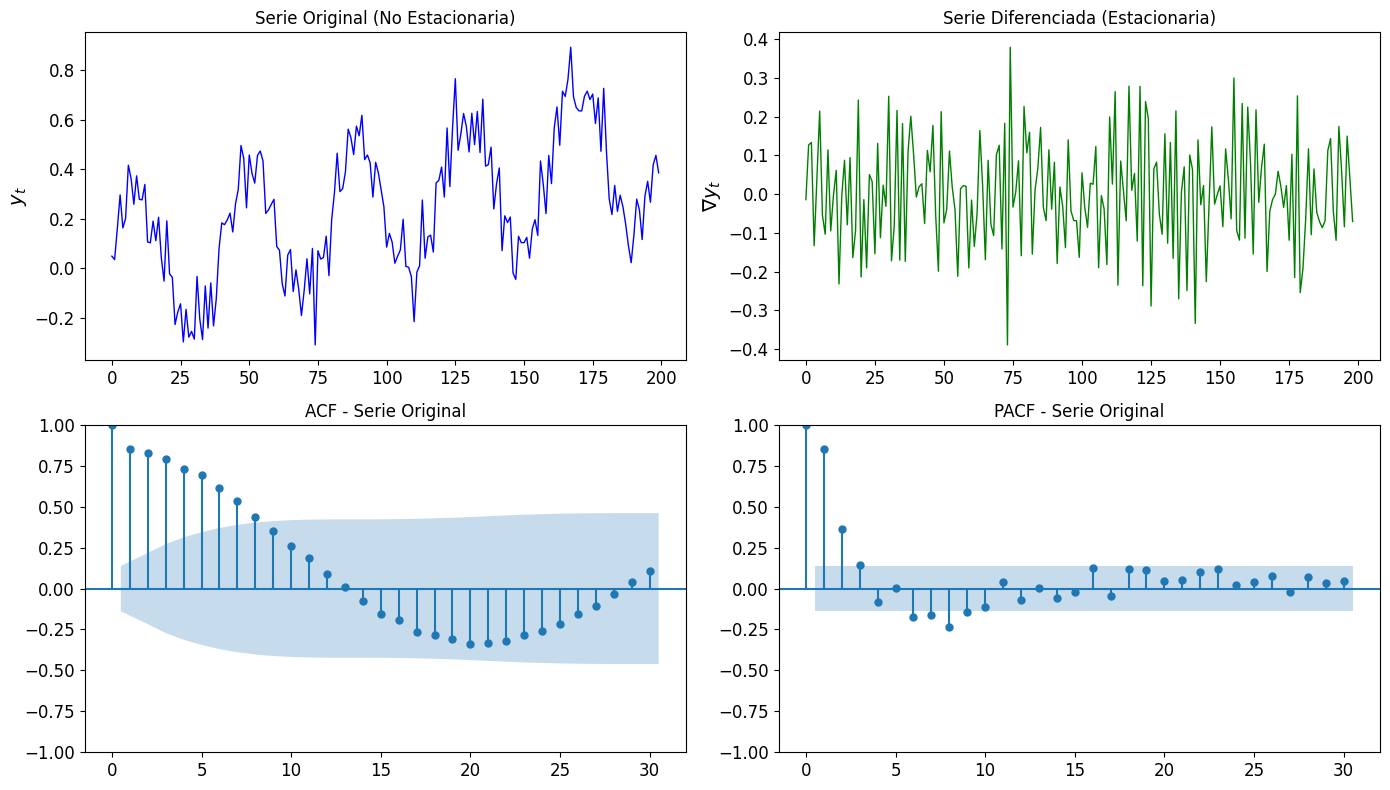


Nota: El ACF lento decayendo sugiere no estacionariedad.
El PACF con picos significativos sugiere componente AR.


In [2]:
# Implementación de MA, ARMA, ARIMA con statsmodels
# pip install statsmodels (si no está instalado)

try:
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
except ImportError:
    print("Instalando statsmodels...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generamos una serie de tiempo de ejemplo
np.random.seed(42)
n_points = 200
t = np.linspace(0, 1, n_points)
# Serie no estacionaria (con tendencia)
trend = 0.5 * t
seasonal = 0.3 * np.sin(2 * np.pi * 5 * t)
noise = 0.1 * np.random.randn(n_points)
y_series = trend + seasonal + noise

# --- 1) Modelo MA(2) ---
print("=" * 60)
print("1. MODELO MA(2)")
print("=" * 60)
try:
    ma_model = sm.tsa.ARIMA(y_series, order=(0, 0, 2))  # order=(p, d, q)
    ma_results = ma_model.fit()
    print(ma_results.summary())
    print(f"AIC: {ma_results.aic:.3f}, BIC: {ma_results.bic:.3f}")
except Exception as e:
    print(f"Error en MA: {e}")

# --- 2) Modelo AR(2) ---
print("\n" + "=" * 60)
print("2. MODELO AR(2)")
print("=" * 60)
try:
    ar_model = sm.tsa.ARIMA(y_series, order=(2, 0, 0))  # order=(p, d, q)
    ar_results = ar_model.fit()
    print(ar_results.summary())
    print(f"AIC: {ar_results.aic:.3f}, BIC: {ar_results.bic:.3f}")
except Exception as e:
    print(f"Error en AR: {e}")

# --- 3) Modelo ARMA(2,2) ---
print("\n" + "=" * 60)
print("3. MODELO ARMA(2,2)")
print("=" * 60)
try:
    arma_model = sm.tsa.ARIMA(y_series, order=(2, 0, 2))  # order=(p, d, q)
    arma_results = arma_model.fit()
    print(arma_results.summary())
    print(f"AIC: {arma_results.aic:.3f}, BIC: {arma_results.bic:.3f}")
except Exception as e:
    print(f"Error en ARMA: {e}")

# --- 4) Modelo ARIMA(2,1,2) (con integración d=1) ---
print("\n" + "=" * 60)
print("4. MODELO ARIMA(2,1,2) - Con diferenciación")
print("=" * 60)
try:
    arima_model = sm.tsa.ARIMA(y_series, order=(2, 1, 2))  # order=(p, d, q)
    arima_results = arima_model.fit()
    print(arima_results.summary())
    print(f"AIC: {arima_results.aic:.3f}, BIC: {arima_results.bic:.3f}")
except Exception as e:
    print(f"Error en ARIMA: {e}")

# --- Visualización de ACF y PACF ---
print("\n" + "=" * 60)
print("5. ANÁLISIS DE AUTOCORRELACIÓN (ACF) Y AUTOCORRELACIÓN PARCIAL (PACF)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original
axes[0, 0].plot(y_series, 'b-', linewidth=1)
axes[0, 0].set_title('Serie Original (No Estacionaria)', fontsize=12)
axes[0, 0].set_ylabel('$y_t$')

# Diferenciada
y_diff = np.diff(y_series)
axes[0, 1].plot(y_diff, 'g-', linewidth=1)
axes[0, 1].set_title('Serie Diferenciada (Estacionaria)', fontsize=12)
axes[0, 1].set_ylabel('$\\nabla y_t$')

# ACF
plot_acf(y_series, lags=30, ax=axes[1, 0], title='ACF - Serie Original')
# PACF
plot_pacf(y_series, lags=30, ax=axes[1, 1], title='PACF - Serie Original')

plt.tight_layout()
plt.show()

print("\nNota: El ACF lento decayendo sugiere no estacionariedad.")
print("El PACF con picos significativos sugiere componente AR.")


# Redes neuronales recurrentes - Recurrent neural networks (RNN)

- Hasta el momento hemos trabajado con datos estructurados tipo tabla, en donde las muestras se asumen independientes e identicamente distribuidas (i.i.d.).

- Sin embargo, para datos secuenciales, la suposición i.i.d no es apropiada, y se requiren de arquitecturas que codifiquen dicha secuencialidad.

- Por ejemplo, en el caso de datos tipo imagen, la relación espacial debe ser codificada apropiadamente, como en el caso de las arquitecturas convolucionales ([Convolutional Neural Networks](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/3_Introduccion_CNN.ipynb)).

- En este sentido, las RNN pretenden explotar la codificación mediante variables latentes, para aproximar el modelado de la incertidumbre de la secuencia como:


$$P(x_t|x_{t-1},\dots,x_1)\approx P(x_t|h_{t-1})$$

donde el estado oculto $h_{t-1}$ (hidden state) codifica la información relevante de la secuencia hasta $t-1$.

- Además, el estado oculto en $t$ se puede calcular a partir de $x_t$ y $h_{t-1},$ como:

$$h_t=f(x_t,h_{t-1})$$

**Nota**: se podría utilizar como $h_t$ todo el vector de datos $x_t,x_{t-1},\dots,x_1$; no obstante, el costo computacional y de memoría sería muy alto.

## Las RNN son redes neuronales con estados ocultos!

- Considere una matriz (mini-lote) de $P$ características desde datos secuenciales $\mathbf{X}_t\in\mathbb{R}^{N\times P}$, es decir, tenemos $N$ trayectorias con $P$ mediciones de una secuencia en el instante $t$.

- Sea $\mathbf{H}_t\in\mathbb{R}^{N \times h}$ la variable oculta (latente) para el instante $t$, la estimación de dicha variable respecto a la entrada actual y a la variable oculta en $t-1$ se puede modelar mediante RNN como:

$$\mathbf{H}_t = \phi(\mathbf{X}_t \mathbf{W}+\mathbf{H}_{t-1}\mathbf{S} + \mathbf{b}),$$

donde $\mathbf{W}\in\mathbb{R}^{P \times h},$ $\mathbf{S}\in\mathbb{R}^{h \times h},$ $\mathbf{b}\in\mathbb{R}^{h}$ y $\phi(\cdot)$ es una función de activación no lineal.

- Si se desea calcular la salida $\mathbf{O}_t\in\mathbb{R}^{N\times Q}$, se puede utilizar la información del estado oculto de la forma:

$$\mathbf{O}_t = \mathbf{H}_t\mathbf{A}+\mathbf{c},$$
donde $\mathbf{A}\in\mathbb{R}^{h\times Q}$, $\mathbf{c}\in\mathbb{R}^{Q}.$

**Esquema de una RNN con un estado oculto:**

![rnn](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn.png?raw=1)



- A continuación se presenta algunos ejemplos sobre Tensorflow para RNN.

Generamos el conjunto de series de tiempo a analizar

In [3]:
#-------------------------------------------------------------------------------
# definimos función para generar señales 1D-------------------------------------
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time   = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)
#-------------------------------------------------------------------------------

In [4]:
#-------------------------------------------------------------------------------
# definimos número de steps y batch_size----------------------------------------
n_steps    = 50
batch_size = 10000
#-------------------------------------------------------------------------------
series           = generate_time_series(batch_size, n_steps + 1)
print('Series dimension:',series.shape)
#-------------------------------------------------------------------------------
# partimos en conjuntos de train/valid/test-------------------------------------
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
#-------------------------------------------------------------------------------
print('Train dimensions:',X_train.shape, y_train.shape)
print('Valid dimensions:',X_valid.shape, y_valid.shape)
print('Test dimensions:',X_test.shape, y_test.shape)
#-------------------------------------------------------------------------------

Series dimension: (10000, 51, 1)
Train dimensions: (7000, 50, 1) (7000, 1)
Valid dimensions: (2000, 50, 1) (2000, 1)
Test dimensions: (1000, 50, 1) (1000, 1)


$[y_{t+P},\dots,y_{t}] = f(y_{t-1},\dots,y_{t-\tau},x_{t},x_{t-1},\dots,x_{t-\tau})$

In [5]:
#-------------------------------------------------------------------------------
y_train # vector de salida
#-------------------------------------------------------------------------------

array([[-0.33051264],
       [ 0.31117982],
       [ 0.20074804],
       ...,
       [-0.58716565],
       [-0.6483902 ],
       [-0.18005343]], dtype=float32)

Generamos la gráfica de las series de tiempo creadas

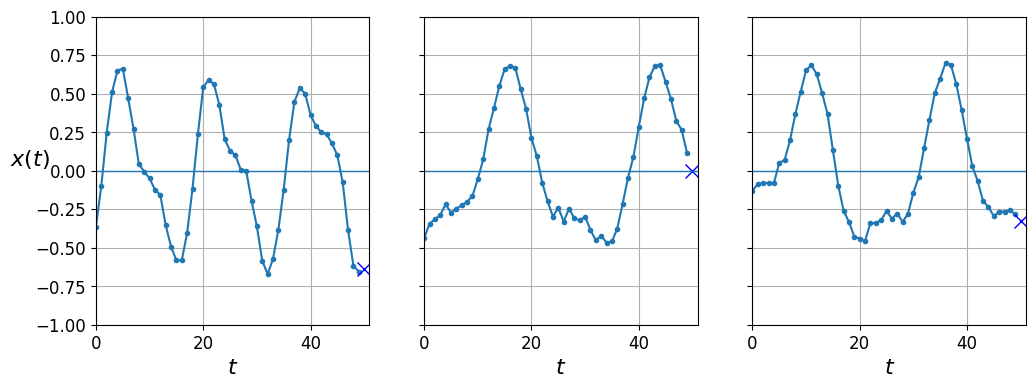

In [6]:
#-------------------------------------------------------------------------------
# definimos función para graficar las series------------------------------------
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
#-------------------------------------------------------------------------------
# graficamos 3 series del set validation----------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()
#-------------------------------------------------------------------------------

# Predicción ingenua (solo predecir el último valor):

- Para ilustrar el concepto de secuencialidad, utilizaremos un predictor ingenuo, en donde la salida actual sería igual al valor en el instante anterior:

$$x_t = x_{t-1}$$

In [7]:
#-------------------------------------------------------------------------------
# asumimos que el valor ha estimar es el último elemento de la serie----------------
y_pred = X_test[:, -1]
#-------------------------------------------------------------------------------
# calculamos el MSE entre el y_valid vs. y_pred---------------------------------

print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

MSE: 2.098642662167549 %


- El error cálculado no es tan grande aparentemente.

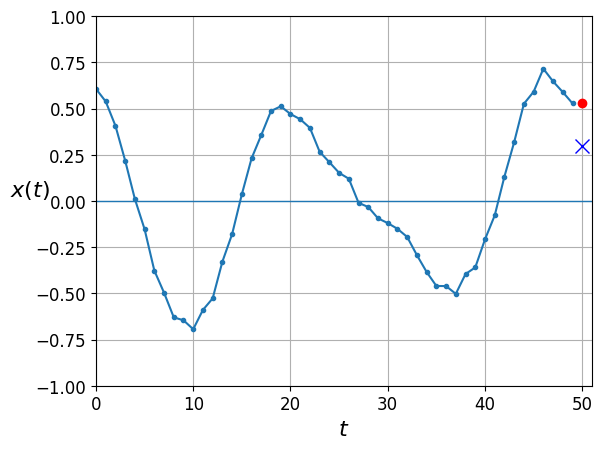

In [8]:
#-------------------------------------------------------------------------------
# graficamos valor estimado----------------------------------------------------
plot_series(X_test[2, :, 0], y_test[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicción lineal

- Ahora utilizaremos un modelo lineal simple.

- Recuerde que como generamos ventanas, podrimos entender esta aproximación como un modelo autorregresivo simple (sin variables latentes):

$$x_t \sim P(x_t|x_{t-1},\dots,x_{t-\tau})$$

donde la estimación de la condicional se realiza mediante un regresor con capas densas.



$\mathbf{X}=[\mathbf{x}_n]\in \mathbb{R}^{N \times P}$

$\mathbf{x}_n =[y_{n-1},y_{n-2},\dots, y_{n-\tau}]$

$\mathbf{y}\in \mathbb{R}^T$

$f(\mathbf{x}_n)=\mathbf{x}_n\mathbf{w}=x_{n1}w_1+\dots+x_{nP}w_P$

$f(\mathbf{x}_n)= y_{n-1}w_1+\dots+y_{n-\tau}w_P = \hat{y}_n$

$P = \tau$

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 51
Trainable params: 51
Non-trainable params: 0
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 51
Trainable params: 51
Non-trainable params: 0
________________________________________________________________

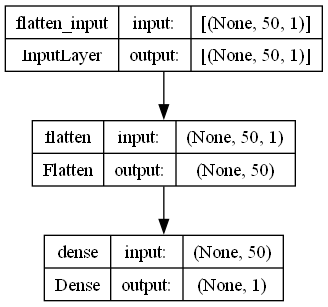

In [9]:
#-------------------------------------------------------------------------------
# definimos un modelo secuencial------------------------------------------------
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])
#-------------------------------------------------------------------------------
model.summary()
#-------------------------------------------------------------------------------
keras.utils.plot_model(model, "my_model_series.png", show_shapes=True)
#-------------------------------------------------------------------------------

Compilamos y ajustamos el modelo usando los datos de train y validation

In [10]:
epochs = 20
#-------------------------------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20


219/219 [==============================] - 2s 4ms/step - loss: 0.1523 - val_loss: 0.0579
Epoch 2/20
219/219 [==============================] - 2s 4ms/step - loss: 0.1523 - val_loss: 0.0579
Epoch 2/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0370 - val_loss: 0.0257
Epoch 3/20
219/219 [==============================] - 1s 4ms/step - loss: 0.0370 - val_loss: 0.0257
Epoch 3/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0181 - val_loss: 0.0141
Epoch 4/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0181 - val_loss: 0.0141
Epoch 4/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0110 - val_loss: 0.0096
Epoch 5/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0110 - val_loss: 0.0096
Epoch 5/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 6/20
219/219 [==============================] - 1s 3ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 6/20


In [11]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

32/32 [==============================] - 0s 1ms/step
MSE: 0.39148544892668724 %
MSE: 0.39148544892668724 %


El resultado es mucho mejor que el predictor ingenuo.

Graficamos el desempeño del modelo secuencial

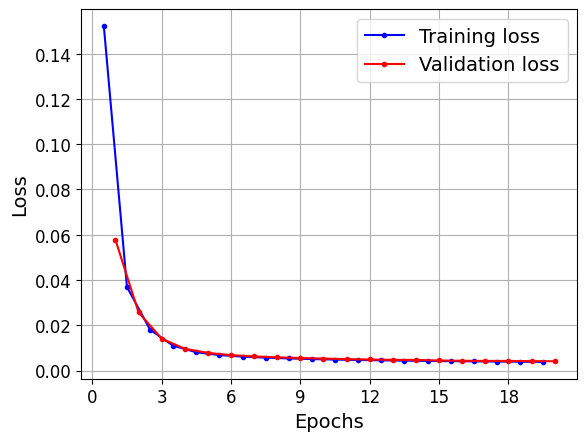

In [12]:
#-------------------------------------------------------------------------------
# definimos una función para plot de curvas de aprendizaje----------------------
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    #plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)
#-------------------------------------------------------------------------------
# llamamos función de plot------------------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

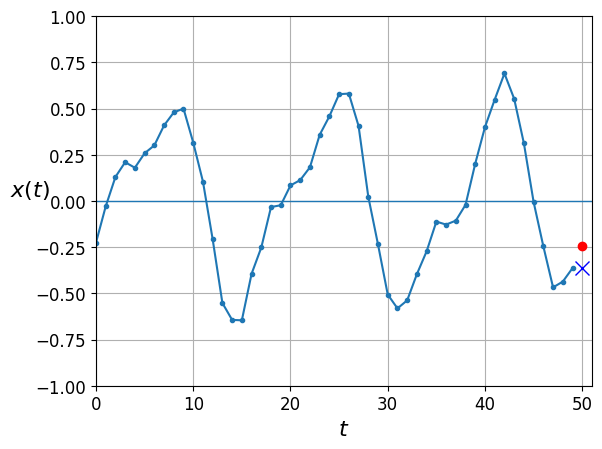

In [13]:
#-------------------------------------------------------------------------------
# pintamos series y predicciones------------------------------------------------
plot_series(X_test[0, :, 0], y_test[0, 0], y_pred[0, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicciones con RNN

- Keras tiene implementado las [capas simples de RNN](https://keras.io/api/layers/recurrent_layers/simple_rnn/).

- Por defecto la activación no lineal utilizada es la `tanh`, aunque se puede trabajar con las vistas en módulos anteriores.

- En este caso se define una única capa RNN con una neurona, dado que tenemos una única salida a predecir.

In [14]:
#-------------------------------------------------------------------------------
# definimos modelo secuencial de RNN simple-------------------------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1], )
])
#-------------------------------------------------------------------------------
# compilamos el modelo RNN------------------------------------------------------
optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
#-------------------------------------------------------------------------------
# entrenamos el modelo y lo ajustamos con los datos de valid--------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 [==============================] - 11s 46ms/step - loss: 0.3443 - val_loss: 0.2431
Epoch 2/20
219/219 [==============================] - 11s 46ms/step - loss: 0.3443 - val_loss: 0.2431
Epoch 2/20
219/219 [==============================] - 10s 44ms/step - loss: 0.1667 - val_loss: 0.1178
Epoch 3/20
219/219 [==============================] - 10s 44ms/step - loss: 0.1667 - val_loss: 0.1178
Epoch 3/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0745 - val_loss: 0.0464
Epoch 4/20
219/219 [==============================] - 10s 44ms/step - loss: 0.0745 - val_loss: 0.0464
Epoch 4/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0286 - val_loss: 0.0186
Epoch 5/20
219/219 [==============================] - 10s 47ms/step - loss: 0.0286 - val_loss: 0.0186
Epoch 5/20
219/219 [==============================] - 10s 46ms/step - loss: 0.0143 - val_loss: 0.0123
Epoch 6/20
219/219 [==============================] - 10s 46ms/step - loss: 0.0143

In [15]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
print('MSE:',np.mean(keras.losses.mse(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------

32/32 [==============================] - 0s 8ms/step
MSE: 1.1502868495881557 %
MSE: 1.1502868495881557 %


Graficamos el performance de la Simple RNN

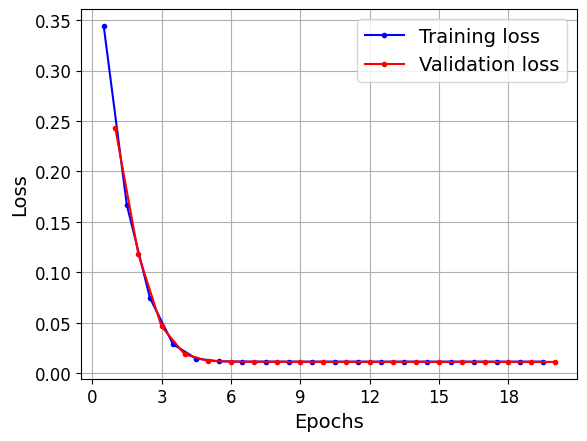

In [16]:
#-------------------------------------------------------------------------------
# graficamos curvas de aprendizaje----------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

Se analiza la predicción

32/32 [==============================] - 0s 10ms/step


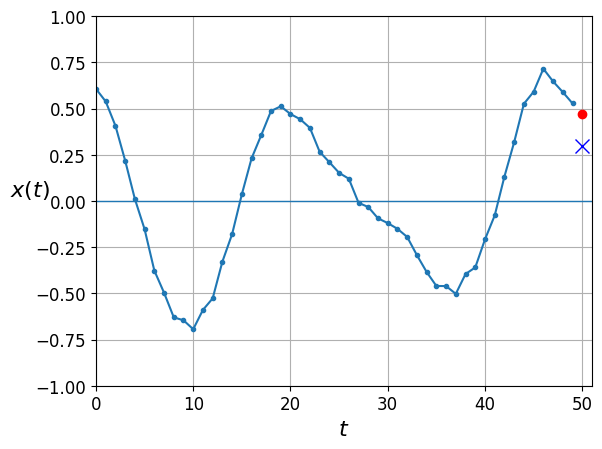

In [17]:
#-------------------------------------------------------------------------------
# evaluamos sobre set de X_valid------------------------------------------------
y_pred = model.predict(X_test)
# pintamos la serie y la predicción---------------------------------------------
plot_series(X_test[2, :, 0], y_test[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Deep RNNs

- Un modelo profundo de RNN contiene $L$ capas ocultas.

- Sobre cada capa oculta, el estado oculto es actualizado y se pasa al siguiente instante de tiempo de la capa actual y de la capa siguiente:

![deeprnn](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/deeprnn.png?raw=1)

- El modelo recurrente profundo se define entonces como:

$$\mathbf{H}^{(l)}_t = \phi_l\left(\mathbf{H}^{(l-1)}_t \mathbf{W}^{(l)}+\mathbf{H}^{(l)}_{t-1}\mathbf{S}^{(l)} + \mathbf{b}^{(l)}\right),$$

donde $\mathbf{W}^{(l)}\in\mathbb{R}^{h_{l-1} \times h_l},$ $\mathbf{S}^{(l)}\in\mathbb{R}^{h_{l-1} \times h_{l-1}},$ $\mathbf{b}\in\mathbb{R}^{h_l}$ y $\phi_l(\cdot)$ es una función de activación no lineal. $\mathbf{H}^{(0)}_t=\mathbf{X}_t$

- Si se desea calcular la salida $\mathbf{O}_t\in\mathbb{R}^{N\times Q}$, se puede utilizar la información del estado oculto en la capa oculta $L$:

$$\mathbf{O}_t = \mathbf{H}^{(L)}_t\mathbf{A}+\mathbf{c},$$
donde $\mathbf{A}\in\mathbb{R}^{h_L\times Q}$, $\mathbf{c}\in\mathbb{R}^{Q}.$


**Nota:** para aplicar la capa densa de la salida, se puede utilizar una capa `SimpleRNN(1)` con una neurona, o una capa densa aplicada desde la capa [TimeDistributed](https://keras.io/api/layers/recurrent_layers/time_distributed/) para preservar la temporalidad de los datos.

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, None, 20)          820       
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 1)                 22        
                                                                 
Total params: 1,282
Trainable params: 1,282
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, None, 20)          820       
                                                                 
 simple_rn

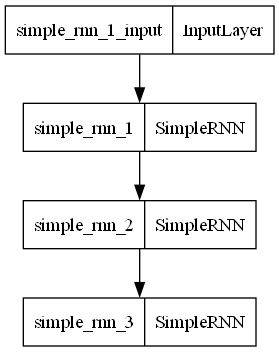

In [18]:
#-------------------------------------------------------------------------------
# definimos el modelo Deep RNN como un stack de SimpleRNN-----------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1,activation='linear')
    ])
#-------------------------------------------------------------------------------
# pintamos el diagrama de bloques del modelo
model.summary()
tf.keras.utils.plot_model(model)
#-------------------------------------------------------------------------------

# Ejercicio 2

- Para el modelo definido, determine los tamaños de las matrices y vectores de bias en cada capa.

**Nota**: Utilice el método `model.layers[l].get_weights()`

## Solución Ejercicio 2: Análisis de pesos y bias en Deep RNN

Analizaremos la estructura de matrices y vectores de bias en cada capa de la arquitectura Deep RNN definida.

**Estructura del modelo**:
- Capa 1: `SimpleRNN(20, return_sequences=True)` - entrada: (batch, 50, 1)
- Capa 2: `SimpleRNN(20, return_sequences=True)` - entrada: (batch, 50, 20)
- Capa 3: `SimpleRNN(1)` - entrada: (batch, 50, 20) → salida: (batch, 1)

**Parámetros en cada capa SimpleRNN**:
Para una capa SimpleRNN con entrada de dimensión $P$ y $h$ unidades ocultas:
- Matriz de pesos de entrada: $\mathbf{W}\in\mathbb{R}^{P \times h}$
- Matriz de pesos recurrentes: $\mathbf{S}\in\mathbb{R}^{h \times h}$
- Vector de bias: $\mathbf{b}\in\mathbb{R}^{h}$

Total parámetros por capa: $P \cdot h + h \cdot h + h = h(P + h + 1)$


In [19]:
# Solución Ejercicio 2: Análisis detallado de pesos y bias

print("=" * 80)
print("ANÁLISIS DE PESOS Y BIAS EN DEEP RNN")
print("=" * 80)

# Accedemos a cada capa del modelo
for layer_idx, layer in enumerate(model.layers):
    print(f"\n{'='*80}")
    print(f"CAPA {layer_idx}: {layer.name} (tipo: {type(layer).__name__})")
    print(f"{'='*80}")
    
    # Obtenemos los pesos y bias
    weights = layer.get_weights()
    
    if len(weights) > 0:
        print(f"Número de matrices de peso: {len(weights)}")
        
        if layer_idx < 2:  # SimpleRNN layers
            W_x, W_h, b = weights  # pesos entrada, pesos recurrentes, bias
            
            print(f"\n1. Matriz de pesos de entrada (W_x):")
            print(f"   Forma: {W_x.shape}")
            print(f"   Tamaño total: {W_x.size} elementos")
            print(f"   Descripción: Conecta entrada (dim={W_x.shape[0]}) → estado oculto (dim={W_x.shape[1]})")
            
            print(f"\n2. Matriz de pesos recurrentes (W_h / S):")
            print(f"   Forma: {W_h.shape}")
            print(f"   Tamaño total: {W_h.size} elementos")
            print(f"   Descripción: Conecta estado oculto anterior (dim={W_h.shape[0]}) → estado oculto nuevo (dim={W_h.shape[1]})")
            
            print(f"\n3. Vector de bias (b):")
            print(f"   Forma: {b.shape}")
            print(f"   Tamaño total: {b.size} elementos")
            print(f"   Descripción: Término aditivo para {b.size} unidades ocultas")
            
            total_params = W_x.size + W_h.size + b.size
            print(f"\n   TOTAL PARÁMETROS EN CAPA {layer_idx}: {total_params}")
            
            # Validación con fórmula teórica
            P_in = W_x.shape[0]  # dimensión entrada
            h = W_x.shape[1]     # número de unidades ocultas
            expected_params = h * (P_in + h + 1)
            print(f"   Verificación teórica: h(P_in + h + 1) = {h}({P_in} + {h} + 1) = {expected_params} ✓")
        
        elif layer_idx == 2:  # SimpleRNN output layer
            W_x, W_h, b = weights
            
            print(f"\n1. Matriz de pesos de entrada (W_x):")
            print(f"   Forma: {W_x.shape}")
            print(f"   Tamaño total: {W_x.size} elementos")
            
            print(f"\n2. Matriz de pesos recurrentes (W_h / S):")
            print(f"   Forma: {W_h.shape}")
            print(f"   Tamaño total: {W_h.size} elementos")
            
            print(f"\n3. Vector de bias (b):")
            print(f"   Forma: {b.shape}")
            print(f"   Tamaño total: {b.size} elementos")
            
            total_params = W_x.size + W_h.size + b.size
            print(f"\n   TOTAL PARÁMETROS EN CAPA {layer_idx}: {total_params}")
    else:
        print("No hay pesos en esta capa.")

print(f"\n{'='*80}")
print("RESUMEN DE PARÁMETROS POR CAPA")
print(f"{'='*80}")

total_model_params = 0
for layer_idx, layer in enumerate(model.layers):
    weights = layer.get_weights()
    if len(weights) > 0:
        layer_params = sum(w.size for w in weights)
        total_model_params += layer_params
        print(f"Capa {layer_idx} ({layer.name:15}): {layer_params:6} parámetros")

print(f"{'-'*40}")
print(f"TOTAL MODELO:                 {total_model_params} parámetros")
print(f"(Verificar con model.count_params() = {model.count_params()})")

# Visualizar algunos valores de ejemplo
print(f"\n{'='*80}")
print("EJEMPLO DE VALORES EN MATRIZ W_x (CAPA 0)")
print(f"{'='*80}")
W_x_sample = model.layers[0].get_weights()[0]
print(f"Primeros 5 valores de W_x:\n{W_x_sample[:5, :3]}")
print(f"\nEstadísticas de W_x:")
print(f"  Media: {W_x_sample.mean():.6f}")
print(f"  Desv. Est.: {W_x_sample.std():.6f}")
print(f"  Min: {W_x_sample.min():.6f}, Max: {W_x_sample.max():.6f}")


ANÁLISIS DE PESOS Y BIAS EN DEEP RNN

CAPA 0: simple_rnn_1 (tipo: SimpleRNN)
Número de matrices de peso: 3

1. Matriz de pesos de entrada (W_x):
   Forma: (1, 20)
   Tamaño total: 20 elementos
   Descripción: Conecta entrada (dim=1) → estado oculto (dim=20)

2. Matriz de pesos recurrentes (W_h / S):
   Forma: (20, 20)
   Tamaño total: 400 elementos
   Descripción: Conecta estado oculto anterior (dim=20) → estado oculto nuevo (dim=20)

3. Vector de bias (b):
   Forma: (20,)
   Tamaño total: 20 elementos
   Descripción: Término aditivo para 20 unidades ocultas

   TOTAL PARÁMETROS EN CAPA 0: 440
   Verificación teórica: h(P_in + h + 1) = 20(1 + 20 + 1) = 440 ✓

CAPA 1: simple_rnn_2 (tipo: SimpleRNN)
Número de matrices de peso: 3

1. Matriz de pesos de entrada (W_x):
   Forma: (20, 20)
   Tamaño total: 400 elementos
   Descripción: Conecta entrada (dim=20) → estado oculto (dim=20)

2. Matriz de pesos recurrentes (W_h / S):
   Forma: (20, 20)
   Tamaño total: 400 elementos
   Descripción: 

In [20]:
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
# entrenamos y ajustamos el modelo----------------------------------------------
history = model.fit(X_train, y_train, epochs=epochs,
                    validation_data=(X_valid, y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 [==============================] - 37s 162ms/step - loss: 0.0616 - val_loss: 0.0095
Epoch 2/20
219/219 [==============================] - 37s 162ms/step - loss: 0.0616 - val_loss: 0.0095
Epoch 2/20
219/219 [==============================] - 36s 163ms/step - loss: 0.0071 - val_loss: 0.0053
Epoch 3/20
219/219 [==============================] - 36s 163ms/step - loss: 0.0071 - val_loss: 0.0053
Epoch 3/20
219/219 [==============================] - 36s 166ms/step - loss: 0.0052 - val_loss: 0.0071
Epoch 4/20
219/219 [==============================] - 36s 166ms/step - loss: 0.0052 - val_loss: 0.0071
Epoch 4/20
219/219 [==============================] - 35s 160ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 5/20
219/219 [==============================] - 35s 160ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 5/20
219/219 [==============================] - 35s 159ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 6/20
219/219 [==============================] - 35s 159ms/step - lo

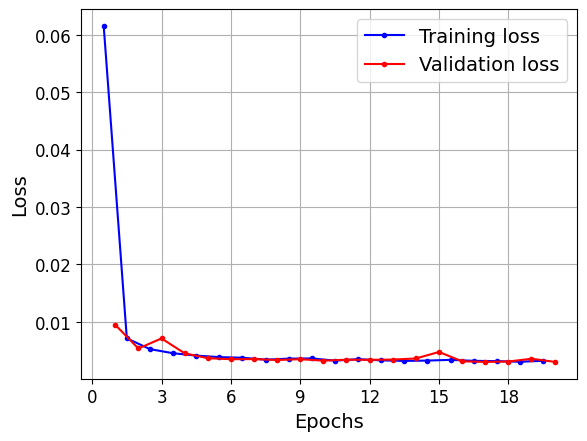

In [21]:
#-------------------------------------------------------------------------------
# graficamos curvas de aprendizaje----------------------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

In [22]:
y_train.shape

(7000, 1)

In [23]:
#-------------------------------------------------------------------------------
# verificamos evluación del modelo---------------------------------------------
y_pred = model.predict(X_test)
#print('MSE:',np.mean(keras.losses.mean_squared_error(y_test, y_pred))*100,'%')
#-------------------------------------------------------------------------------
y_pred.shape

32/32 [==============================] - 1s 22ms/step


(1000, 1)

Graficamos el performance de la Deep RNN

63/63 [==============================] - 1s 23ms/step


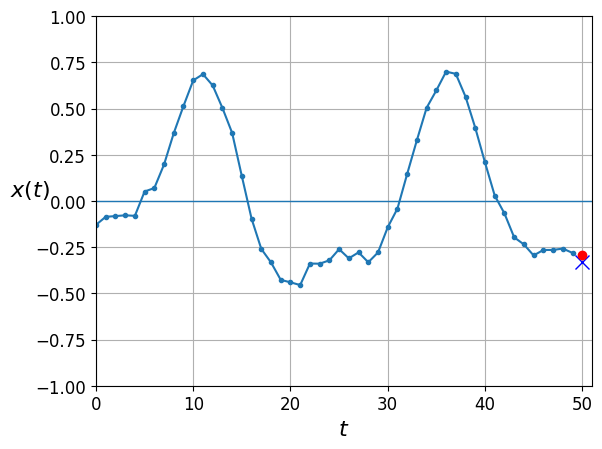

In [24]:
#-------------------------------------------------------------------------------
# evaluamos sobre set de X_valid------------------------------------------------
y_pred = model.predict(X_valid)
# pintamos la serie y la predicción---------------------------------------------
plot_series(X_valid[2, :, 0], y_valid[2, 0], y_pred[2, 0])
plt.show()
#-------------------------------------------------------------------------------

# Predicir un horizonte más lejano

- Si concatenamos las predicciones de a una muestra, para generar salidas con horizontes más lejanos, podemos estar propangando el error!

In [25]:
#-------------------------------------------------------------------------------
# definimos nueva semilla aleatoria---------------------------------------------
np.random.seed(43) #
#-------------------------------------------------------------------------------
# generamos nueva series de tiempo----------------------------------------------
series       = generate_time_series(1, n_steps + 10)     # horizonte de 10 valores en el tiempo
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X            = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)
#-------------------------------------------------------------------------------
Y_pred = X[:, n_steps:]
#-------------------------------------------------------------------------------

1/1 [==============================] - 0s 42ms/step


In [26]:
#-------------------------------------------------------------------------------
# observamos nuevas dimensiones de Y_pred---------------------------------------
Y_pred.shape #horizonte de 10 valores en el tiempo
#-------------------------------------------------------------------------------

(1, 10, 1)

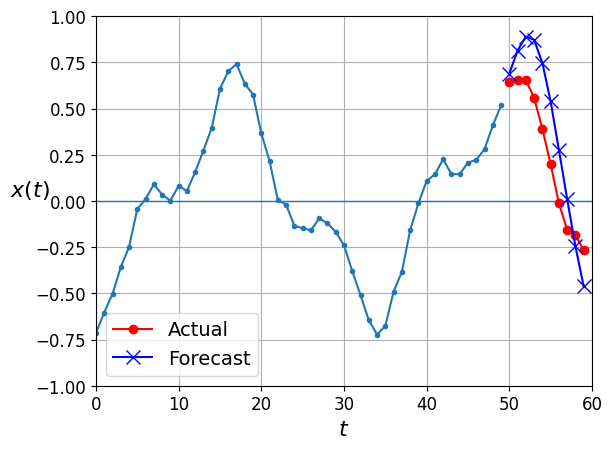

In [27]:
#-------------------------------------------------------------------------------
# definimos función para pintar forecast----------------------------------------
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)
#-------------------------------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- Lo mejor es entrenar un modelo que incluya como salida target los siguientes $T$ valores a predicir en el horizonte.

- Se requiere entonces generar nuevamente la secuencia con $T-1$ pasos más en el tiempo.

In [28]:
#-------------------------------------------------------------------------------
# definimos semilla aleatoria---------------------------------------------------
np.random.seed(42)
#-------------------------------------------------------------------------------
n_steps = 50
series = generate_time_series(10000, n_steps + 10)
print('Series dimension:',series.shape)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]
#-------------------------------------------------------------------------------
print('Train dimensions:',X_train.shape, Y_train.shape)
print('Valid dimensions:',X_valid.shape, Y_valid.shape)
print('Test dimensions:',X_test.shape, Y_test.shape)
#-------------------------------------------------------------------------------

Series dimension: (10000, 60, 1)
Train dimensions: (7000, 50, 1) (7000, 10)
Valid dimensions: (2000, 50, 1) (2000, 10)
Test dimensions: (1000, 50, 1) (1000, 10)


Predicción de los siguientes 10 valores (uno a uno y concatenar):

In [29]:
#-------------------------------------------------------------------------------
# realizamos predicción usando modelo Deep RNN----------------------------------
del X
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)
#-------------------------------------------------------------------------------
# obtenemos las predicciones de los siguientes 10 valores-----------------------
Y_pred = X[:, n_steps:, 0]
#-------------------------------------------------------------------------------
print('Y_pred dimensions:', Y_pred.shape)
#-------------------------------------------------------------------------------

63/63 [==============================] - 2s 25ms/step
Y_pred dimensions: (2000, 10)
Y_pred dimensions: (2000, 10)


- Error de predicción con horizontes mayores a 1 concatenando salidas:

In [30]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_valid, Y_pred))*100,'%')
#-------------------------------------------------------------------------------

4.399917647242546 %


Ahora se crea una RNN que permita predecir los siguientes 10 valores en una sola evaluación (predicción multi-salida):

In [31]:
#-------------------------------------------------------------------------------
# definimos semillas aleatorias-------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
# definimos el modelo secuencial multi-salida-----------------------------------
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10) # capa densa para estimar los siguientes 10 valores
])
#-------------------------------------------------------------------------------
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam")
#-------------------------------------------------------------------------------
# entrenamos y ajustamos el modelo----------------------------------------------
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 [==============================] - 26s 113ms/step - loss: 0.0511 - val_loss: 0.0280
Epoch 2/20
219/219 [==============================] - 26s 113ms/step - loss: 0.0511 - val_loss: 0.0280
Epoch 2/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0232 - val_loss: 0.0170
Epoch 3/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0232 - val_loss: 0.0170
Epoch 3/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0153 - val_loss: 0.0141
Epoch 4/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0153 - val_loss: 0.0141
Epoch 4/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0131 - val_loss: 0.0136
Epoch 5/20
219/219 [==============================] - 25s 113ms/step - loss: 0.0131 - val_loss: 0.0136
Epoch 5/20
219/219 [==============================] - 24s 110ms/step - loss: 0.0122 - val_loss: 0.0099
Epoch 6/20
219/219 [==============================] - 24s 110ms/step - lo

In [32]:
#-------------------------------------------------------------------------------
# generamos nuevos datos, con nueva semilla aleatoria---------------------------
np.random.seed(43)
#-------------------------------------------------------------------------------
# generamos nueva serie de tiempo-----------------------------------------------
series       = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
#-------------------------------------------------------------------------------
print('X_new dimensions:',X_new.shape)
print('Y_new dimensions:',Y_new.shape)
#-------------------------------------------------------------------------------
# hacemos predicción de los 10 últimos valores----------------------------------
Y_pred       = model.predict(X_new)[..., np.newaxis]
print('Y_pred dimensions:',Y_pred.shape)
#-------------------------------------------------------------------------------

X_new dimensions: (1, 50, 1)
Y_new dimensions: (1, 10, 1)
1/1 [==============================] - 0s 269ms/step
Y_pred dimensions: (1, 10, 1)
1/1 [==============================] - 0s 269ms/step
Y_pred dimensions: (1, 10, 1)


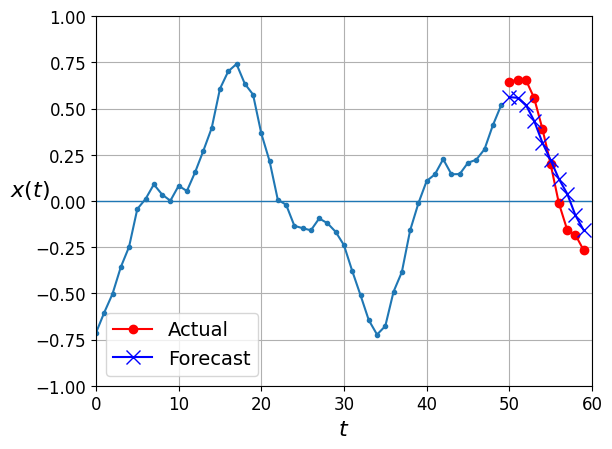

In [33]:
#-------------------------------------------------------------------------------
# graficamos el forecast--------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- El error de predicción mejora:

In [34]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

1.3489489443600178 %


# El problema de las dependencias a largo plazo

- Uno de los atractivos de los RNN es la idea de conectar la información anterior a la tarea actual. Si los RNN pudieran hacer esto, serían extremadamente útiles.

- A veces, solo necesitamos mirar información reciente para realizar la tarea actual.

- Por ejemplo, considere un modelo de lenguaje que intenta predecir la siguiente palabra basándose en las anteriores. Si estamos tratando de predecir la última palabra en la oración:

 "las nubes están en el cielo",

no necesitamos ningún contexto adicional; es bastante obvio que la siguiente palabra será **cielo**.

- En tales casos, donde la brecha entre la información relevante y el lugar que se necesita es pequeña, los RNN pueden aprender a usar la información del pasado.

![rnn_corto](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn_corto.png?raw=1)

- Pero también hay casos en los que necesitamos más contexto. Considere intentar predecir la última palabra del texto:

"Crecí en Francia ... hablo francés con fluidez",

la información reciente sugiere que la siguiente palabra es probablemente el **nombre de un idioma**, pero si queremos delimitar qué idioma, necesitamos el contexto de Francia, desde más atrás.

- Entonces, la brecha entre la información relevante y el punto donde se necesita puede ser grande.

![rnn_largo](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/rnn_largo.png?raw=1)

- En teoría, los RNN son capaces de manejar tales "dependencias a largo plazo". Lamentablemente, en la práctica, las RNN no parecen ser capaces de aprenderlos.

# [LSTM](https://colah.github.io/posts/2015-08-Understanding-LSTMs/): Long short term memory

- La LSTM pretende aprender dependencias largas.

- En general, en LSTM, y su extensión GRU, buscan crear mecanismos que permitan identificar cuando el estado oculto debe ser actualizado y cuando reseteado.

- A diferencia de una capa RNN simple, las LSTMs presenta cuatro (4) capas interactuando:


![lstm](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/lstm.png?raw=1)

con:

$$\mathbf{I}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xi}+\mathbf{H}_{t-1}\mathbf{W}_{hi}+\mathbf{b}_i\right)$$
$$\mathbf{F}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xf}+\mathbf{H}_{t-1}\mathbf{W}_{hf}+\mathbf{b}_f\right)$$
$$\mathbf{O}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xo}+\mathbf{H}_{t-1}\mathbf{W}_{ho}+\mathbf{b}_o\right)$$
$$\tilde{\mathbf{C}}_t = \tanh\left(\mathbf{X}_t\mathbf{W}_{xc}+\mathbf{H}_{t-1}\mathbf{W}_{hc}+\mathbf{b}_c\right)$$
$${\mathbf{C}}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t $$
$${\mathbf{H}}_t = \mathbf{O}_t \odot \tanh{(\mathbf{C}_{t})} $$


donde $\mathbf{W}_{xi},\mathbf{W}_{xf},\mathbf{W}_{xo}, \mathbf{W}_{xc}\in\mathbb{R}^{P\times h},$ $\mathbf{W}_{hi},\mathbf{W}_{hf},\mathbf{W}_{ho},\mathbf{W}_{hc}\in\mathbb{R}^{h\times h}$ y $\mathbf{b}_{i},\mathbf{b}_{f},\mathbf{b}_{o}, \mathbf{b}_{c}\in\mathbb{R}^{h}$.

- $\mathbf{I}_t$ busca codificar "cuanto" considerar de los datos nuevos y $\mathbf{F}_t$ que tando retenemos de los datos del pasado.

- Si la compuerta de salida se aproxima a 1, pasamos toda la información de la memoría al predictor, pero, si la compuerta de la salida aproxima a 0, se retiene la información en la celda de memoría.


In [35]:
#-------------------------------------------------------------------------------
# generamos los datos-----------------------------------------------------------
np.random.seed(42)
#-------------------------------------------------------------------------------
# generamos series de tiempo----------------------------------------------------
n_steps = 50
series  = generate_time_series(10000, n_steps + 10)
print('Series dimensions:',series.shape)
#-------------------------------------------------------------------------------
# partimos los datos en train/valid/test----------------------------------------
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test  = series[9000:, :n_steps]
print('X_train dimensions:',X_train.shape)
print('X_valid dimensions:',X_valid.shape)
print('X_test dimensions:',X_test.shape)
#-------------------------------------------------------------------------------
# definimos nuevos Y------------------------------------------------------------
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
print('Y dimensions:',Y.shape)
#-------------------------------------------------------------------------------
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test  = Y[9000:]
#-------------------------------------------------------------------------------
print('Y_train dimensions:', Y_train.shape)
print('Y_valid dimensions:',Y_valid.shape)
print('Y_test dimensions:',Y_test.shape)
#-------------------------------------------------------------------------------

Series dimensions: (10000, 60, 1)
X_train dimensions: (7000, 50, 1)
X_valid dimensions: (2000, 50, 1)
X_test dimensions: (1000, 50, 1)
Y dimensions: (10000, 50, 10)
Y_train dimensions: (7000, 50, 10)
Y_valid dimensions: (2000, 50, 10)
Y_test dimensions: (1000, 50, 10)


**Nota**: En la capa de salida se puede utilizar una capa densa de 10 neuronas (horizonte de 10 valores). No obstante, debe aplicarse la capa [TimeDistributed](https://keras.io/api/layers/recurrent_layers/time_distributed/) para aplicar la operación densa sobre cada tramo de tiempo.

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, None, 20)          1760      
                                                                 
 lstm_1 (LSTM)               (None, None, 20)          3280      
                                                                 
 time_distributed (TimeDistr  (None, None, 10)         210       
 ibuted)                                                         
                                                                 
Total params: 5,250
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, None, 20)          1760      
                                                                 
 lstm_1 (LSTM)               (None, None, 20)          3280      
                                  

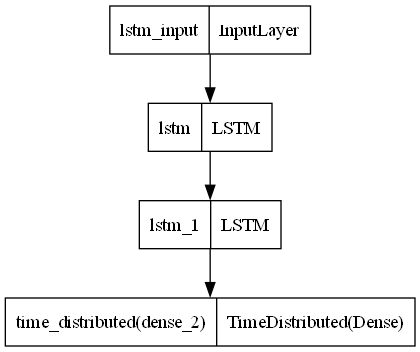

In [36]:
#-------------------------------------------------------------------------------
# definimos semilla aleatoria---------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
#-------------------------------------------------------------------------------
def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mse(Y_true[:, -1], Y_pred[:, -1])
#-------------------------------------------------------------------------------
# definimos el modelo secuencial con 2 capas LSTM-------------------------------
model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.summary()
tf.keras.utils.plot_model(model)

In [37]:
#-------------------------------------------------------------------------------
# compilamos el modelo----------------------------------------------------------
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
#-------------------------------------------------------------------------------
# entrenamos y validamos el modelo----------------------------------------------
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))
#-------------------------------------------------------------------------------

Epoch 1/20
219/219 [==============================] - 13s 18ms/step - loss: 0.0782 - last_time_step_mse: 0.0629 - val_loss: 0.0536 - val_last_time_step_mse: 0.0316
Epoch 2/20
219/219 [==============================] - 13s 18ms/step - loss: 0.0782 - last_time_step_mse: 0.0629 - val_loss: 0.0536 - val_last_time_step_mse: 0.0316
Epoch 2/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0470 - last_time_step_mse: 0.0248 - val_loss: 0.0420 - val_last_time_step_mse: 0.0200
Epoch 3/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0470 - last_time_step_mse: 0.0248 - val_loss: 0.0420 - val_last_time_step_mse: 0.0200
Epoch 3/20
219/219 [==============================] - 4s 18ms/step - loss: 0.0385 - last_time_step_mse: 0.0170 - val_loss: 0.0366 - val_last_time_step_mse: 0.0158
Epoch 4/20
219/219 [==============================] - 4s 18ms/step - loss: 0.0385 - last_time_step_mse: 0.0170 - val_loss: 0.0366 - val_last_time_step_mse: 0.0158
Epoch 4/20
219/219 [

In [38]:
#-------------------------------------------------------------------------------
# evaluamos el modelo sobre los datos de Valid----------------------------------
model.evaluate(X_test, Y_test)
#-------------------------------------------------------------------------------

32/32 [==============================] - 0s 6ms/step - loss: 0.0238 - last_time_step_mse: 0.0083


[0.023845070973038673, 0.008282010443508625]

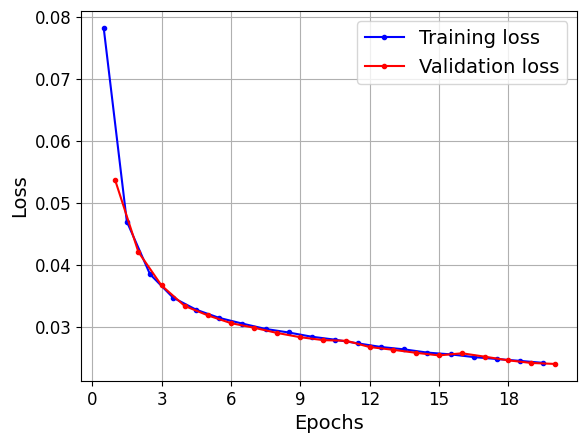

In [39]:
#-------------------------------------------------------------------------------
# observamos las curvas de aprendizaje del modelo-------------------------------
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()
#-------------------------------------------------------------------------------

In [40]:
#-------------------------------------------------------------------------------
# generamos una nueva serie de tiempo para testear el modelo--------------------
np.random.seed(43)
#-------------------------------------------------------------------------------
# generamos nueva sample--------------------------------------------------------
series       = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
#-------------------------------------------------------------------------------
# realizamos predicción---------------------------------------------------------
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]
#-------------------------------------------------------------------------------

1/1 [==============================] - 1s 509ms/step


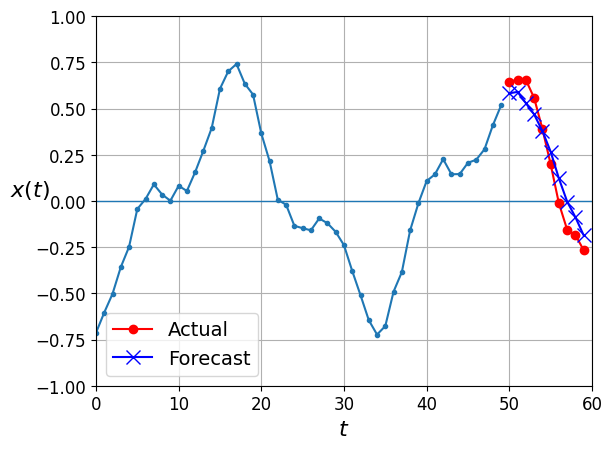

In [41]:
#-------------------------------------------------------------------------------
# graficamos el forecast--------------------------------------------------------
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()
#-------------------------------------------------------------------------------

- Rendimientos similares a las RNN con horizonte lejano.
- Es preciso sintonizar número de capas e hiperparámetros para aprovechar todas las ventajas de LSTM.

In [42]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

0.9386672638356686 %


# [GRU](https://towardsdatascience.com/understanding-gru-networks-2ef37df6c9be): Gated Recurrent Unit

- La GRU puede entenderse como una extensión de la capa LSTM para evitar problemas de convergencia en el gradiente.

$$\mathbf{R}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xr}+\mathbf{H}_{t-1}\mathbf{W}_{hr}+\mathbf{b}_r\right)$$
$$\mathbf{Z}_t = \sigma\left(\mathbf{X}_t\mathbf{W}_{xz}+\mathbf{H}_{t-1}\mathbf{W}_{hz}+\mathbf{b}_z\right)$$
$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t\mathbf{W}_{xh}+(\mathbf{R}_t\odot\mathbf{H}_{t-1})\mathbf{W}_{hh}+\mathbf{b}_h)$$
$${\mathbf{H}}_t = \mathbf{Z}_t\odot\mathbf{H}_{t-1}+(1-\mathbf{Z}_t)\odot\tilde{\mathbf{H}}_t$$

donde $\mathbf{W}_{xh},\mathbf{W}_{xz},\mathbf{W}_{xh}\in\mathbb{R}^{P\times h},$ $\mathbf{W}_{hr},\mathbf{W}_{hz},\mathbf{W}_{hh}\in\mathbb{R}^{h\times h}$ y $\mathbf{b}_{r},\mathbf{b}_{z},\mathbf{b}_{h}\in\mathbb{R}^{h}$.

![gru](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/gru.png?raw=1)

- Si las entradas de $\mathbf{R}_t$ se acercan a 1, el modelo se convierte en una RNN simple. Para valores en $\mathbf{R}_t$ cercanos a 0, el estado oculto "candidato" se cácula como un MLP sobre $\mathbf{X}_t$, cualquier estado oculto anterior es "reseteado".

- Además, si los elementos de la compuerta de actualización $\mathbf{Z}_t$ son cercanos a 1, se mantiene el estado anterior en la capa, de lo contrario el nuevo estado $\mathbf{H}_t$ "acepta" el estado candidato $\tilde{\mathbf{H}}_t.$

- Lo anterior permite mitigar el efecto del desvanecimiento del gradiente de las RNN simples, codificando mejor dependencias en series con relaciones "relativamente grandes" en el tiempo.



In [43]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=epochs,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 [==============================] - 6s 18ms/step - loss: 0.0733 - last_time_step_mse: 0.0647 - val_loss: 0.0541 - val_last_time_step_mse: 0.0427
Epoch 2/20
219/219 [==============================] - 6s 18ms/step - loss: 0.0733 - last_time_step_mse: 0.0647 - val_loss: 0.0541 - val_last_time_step_mse: 0.0427
Epoch 2/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0494 - last_time_step_mse: 0.0387 - val_loss: 0.0461 - val_last_time_step_mse: 0.0351
Epoch 3/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0494 - last_time_step_mse: 0.0387 - val_loss: 0.0461 - val_last_time_step_mse: 0.0351
Epoch 3/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0441 - last_time_step_mse: 0.0331 - val_loss: 0.0412 - val_last_time_step_mse: 0.0296
Epoch 4/20
219/219 [==============================] - 3s 15ms/step - loss: 0.0441 - last_time_step_mse: 0.0331 - val_loss: 0.0412 - val_last_time_step_mse: 0.0296
Epoch 4/20
219/219 [==

In [44]:
model.evaluate(X_valid, Y_valid)

63/63 [==============================] - 0s 6ms/step - loss: 0.0223 - last_time_step_mse: 0.0078


[0.022286126390099525, 0.007764796726405621]

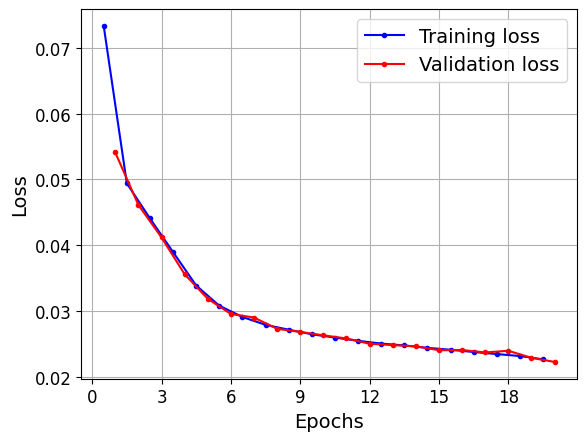

In [45]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [46]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 [==============================] - 0s 448ms/step


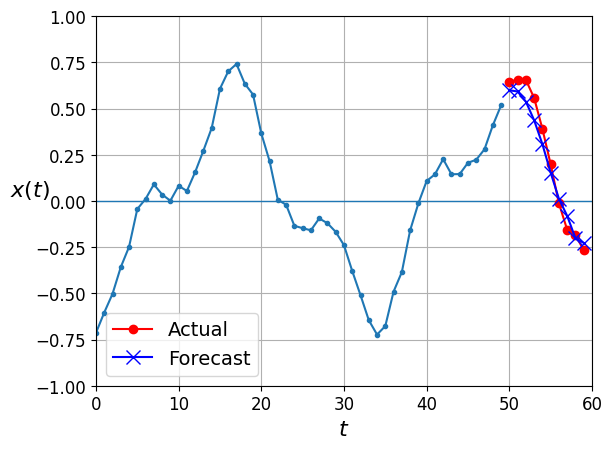

In [47]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [48]:
#-------------------------------------------------------------------------------
# calculamos el MSE de la predicción--------------------------------------------
print(np.mean(keras.metrics.mse(Y_new, Y_pred))*100,'%')

0.5167520605027676 %


# Ejercicio 3:

- Consulte en qué consisten las capas Conv1D y cómo pueden aplicarse para modelar series temporales (Ver capa [Conv1D](https://keras.io/api/layers/convolution_layers/convolution1d/) y [ejemplo](https://boostedml.com/2020/04/1-d-convolutional-neural-networks-for-time-series-basic-intuition.html)).

- Realice una comparación entre las redes tipo RNN simple, LSTM, GRU y Conv1D en terminos de la capacidad de predicción en términos del mse y el mae, en los datos simulados para diferentes horizontes: $\{1,2,3,\dots,15\}$

## Solución Ejercicio 3: Comparación de RNN, LSTM, GRU y Conv1D

Comparamos el desempeño de cuatro arquitecturas en predicción de series temporales para múltiples horizontes:
- **SimpleRNN**: Red recurrente simple
- **LSTM**: Long Short-Term Memory (mejor para dependencias largas)
- **GRU**: Gated Recurrent Unit (más ligero que LSTM)
- **Conv1D**: Convolucional 1D (captura patrones locales y globales)

**Métricas**:
- **MSE** (Mean Squared Error): Error cuadrático medio
- **MAE** (Mean Absolute Error): Error absoluto medio

**Horizontes**: Predicción de 1, 3, 5, 10 y 15 pasos hacia adelante.

### Arquitectura Conv1D para series temporales

La capa `Conv1D` aplica filtros convolucionales sobre secuencias temporales:
- **Kernel size**: Tamaño de la ventana (ej: 3 captura patrones de 3 pasos)
- **Padding "causal"**: Evita "futuro" contaminando pasado (crucial en series)
- **GlobalAveragePooling1D**: Reduce dimensión espacial.

Ventajas: Captura patrones locales con menos parámetros que RNN/LSTM.


COMPARACIÓN DE ARQUITECTURAS: RNN, LSTM, GRU, Conv1D

Preparando datasets...
X_train: (3000, 50, 1), Y_train: (3000, 15)
X_test: (1000, 50, 1), Y_test: (1000, 15)

ENTRENANDO Y EVALUANDO MODELOS

>>> Horizonte: 1 pasos
  - Entrenando RNN... WARNING:tensorflow:5 out of the last 571 calls to <function Model.make_predict_function.<locals>.predict_function at 0x000002A7F5493A60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
MSE: 0.003098, MAE: 0.044427, Tiempo: 26.88s
  - Entren

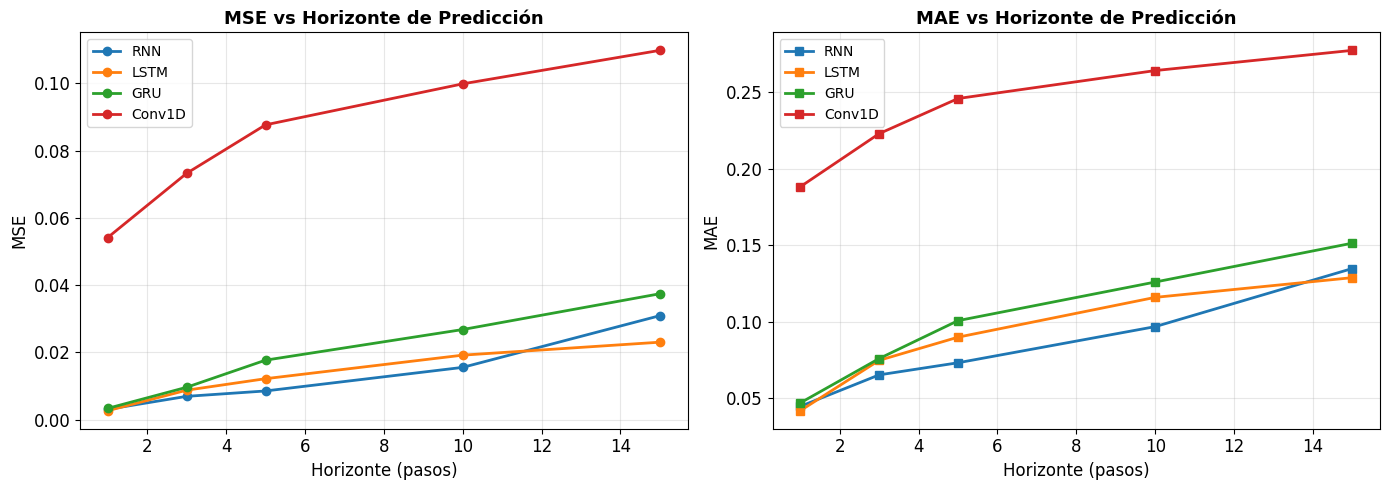


CONCLUSIONES

Mejor modelo por horizonte (MSE):
  Horizonte  1: LSTM       (MSE=0.002686)
  Horizonte  3: RNN        (MSE=0.006956)
  Horizonte  5: RNN        (MSE=0.008557)
  Horizonte 10: RNN        (MSE=0.015572)
  Horizonte 15: LSTM       (MSE=0.023064)

Observaciones:
  • LSTM/GRU generalmente superan a RNN simple para horizontes largos
    (capturan mejor dependencias a largo plazo).
  • Conv1D es competitivo y más rápido de entrenar en algunos casos.
  • El error (MSE/MAE) tiende a crecer con horizontes más lejanos
    (propagación de errores inevitable en predicción multi-paso).


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import time

print("=" * 80)
print("COMPARACIÓN DE ARQUITECTURAS: RNN, LSTM, GRU, Conv1D")
print("=" * 80)

# Función para preparar datasets con múltiples horizontes
def preparar_dataset(max_horizon=15, n_series=4000, n_steps=50, seed=123):
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    series = generate_time_series(n_series, n_steps + max_horizon)
    X_tmp = series[:, :n_steps]
    Y_tmp = np.empty((n_series, max_horizon))
    for h in range(1, max_horizon + 1):
        Y_tmp[:, h - 1] = series[:, n_steps + h - 1, 0]
    return X_tmp, Y_tmp

# Funciones constructoras de modelos
def make_rnn(horizon):
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(32, input_shape=[None, 1]),
        keras.layers.Dense(horizon),
    ])
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

def make_lstm(horizon):
    model = keras.models.Sequential([
        keras.layers.LSTM(32, input_shape=[None, 1]),
        keras.layers.Dense(horizon),
    ])
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

def make_gru(horizon):
    model = keras.models.Sequential([
        keras.layers.GRU(32, input_shape=[None, 1]),
        keras.layers.Dense(horizon),
    ])
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

def make_conv1d(horizon):
    model = keras.models.Sequential([
        keras.layers.Conv1D(32, kernel_size=3, padding="causal", activation="relu", input_shape=[None, 1]),
        keras.layers.Conv1D(32, kernel_size=3, padding="causal", activation="relu"),
        keras.layers.GlobalAveragePooling1D(),
        keras.layers.Dense(horizon),
    ])
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

# Preparar datos
print("\nPreparando datasets...")
X_all, Y_all = preparar_dataset(max_horizon=15, n_series=4000, n_steps=50, seed=321)
X_train, X_test = X_all[:3000], X_all[3000:]
Y_train, Y_test = Y_all[:3000], Y_all[3000:]
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

# Diccionario de modelos
modelos = {
    "RNN": make_rnn,
    "LSTM": make_lstm,
    "GRU": make_gru,
    "Conv1D": make_conv1d,
}

# Almacenar resultados
resultados = []
horizons_list = [1, 3, 5, 10, 15]

print(f"\n{'='*80}")
print("ENTRENANDO Y EVALUANDO MODELOS")
print(f"{'='*80}")

for horizon in horizons_list:
    print(f"\n>>> Horizonte: {horizon} pasos")
    
    y_train_h = Y_train[:, :horizon]
    y_test_h = Y_test[:, :horizon]
    
    for nombre, builder in modelos.items():
        print(f"  - Entrenando {nombre}...", end=" ", flush=True)
        
        model = builder(horizon)
        t0 = time.time()
        history = model.fit(
            X_train,
            y_train_h,
            epochs=15,
            batch_size=64,
            validation_split=0.1,
            verbose=0,
        )
        tiempo_train = time.time() - t0
        
        # Predicción
        pred = model.predict(X_test, verbose=0)
        
        # Métricas
        mse = mean_squared_error(y_test_h.reshape(-1, horizon), pred.reshape(-1, horizon))
        mae = mean_absolute_error(y_test_h.reshape(-1, horizon), pred.reshape(-1, horizon))
        
        resultados.append({
            "Modelo": nombre,
            "Horizonte": horizon,
            "MSE": mse,
            "MAE": mae,
            "Tiempo (s)": tiempo_train,
        })
        
        print(f"MSE: {mse:.6f}, MAE: {mae:.6f}, Tiempo: {tiempo_train:.2f}s")

# Crear tabla de resultados
df_resultados = pd.DataFrame(resultados)

print(f"\n{'='*80}")
print("TABLA RESUMEN DE RESULTADOS")
print(f"{'='*80}")
print(df_resultados.to_string(index=False))

# Análisis por horizonte
print(f"\n{'='*80}")
print("MSE POR HORIZONTE (ARQUITECTURA × HORIZONTE)")
print(f"{'='*80}")
df_mse = df_resultados.pivot(index="Modelo", columns="Horizonte", values="MSE")
print(df_mse)

print(f"\n{'='*80}")
print("MAE POR HORIZONTE (ARQUITECTURA × HORIZONTE)")
print(f"{'='*80}")
df_mae = df_resultados.pivot(index="Modelo", columns="Horizonte", values="MAE")
print(df_mae)

# Gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE vs Horizonte
for modelo in modelos.keys():
    data = df_resultados[df_resultados["Modelo"] == modelo]
    axes[0].plot(data["Horizonte"], data["MSE"], marker="o", label=modelo, linewidth=2)
axes[0].set_xlabel("Horizonte (pasos)", fontsize=12)
axes[0].set_ylabel("MSE", fontsize=12)
axes[0].set_title("MSE vs Horizonte de Predicción", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# MAE vs Horizonte
for modelo in modelos.keys():
    data = df_resultados[df_resultados["Modelo"] == modelo]
    axes[1].plot(data["Horizonte"], data["MAE"], marker="s", label=modelo, linewidth=2)
axes[1].set_xlabel("Horizonte (pasos)", fontsize=12)
axes[1].set_ylabel("MAE", fontsize=12)
axes[1].set_title("MAE vs Horizonte de Predicción", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de conclusiones
print(f"\n{'='*80}")
print("CONCLUSIONES")
print(f"{'='*80}")

best_mse_models = df_resultados.loc[df_resultados.groupby("Horizonte")["MSE"].idxmin()]
best_mae_models = df_resultados.loc[df_resultados.groupby("Horizonte")["MAE"].idxmin()]

print("\nMejor modelo por horizonte (MSE):")
for _, row in best_mse_models.iterrows():
    print(f"  Horizonte {row['Horizonte']:2d}: {row['Modelo']:10} (MSE={row['MSE']:.6f})")

print("\nObservaciones:")
print("  • LSTM/GRU generalmente superan a RNN simple para horizontes largos")
print("    (capturan mejor dependencias a largo plazo).")
print("  • Conv1D es competitivo y más rápido de entrenar en algunos casos.")
print("  • El error (MSE/MAE) tiende a crecer con horizontes más lejanos")
print("    (propagación de errores inevitable en predicción multi-paso).")
